In [164]:
from sklearn.calibration import CalibratedClassifierCV
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from typing import Tuple, Optional, Union, List, Dict, Any
from pathlib import Path
from dataclasses import dataclass, field
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, 
    precision_recall_curve, average_precision_score, confusion_matrix, classification_report
)
from pytorch_tabnet.tab_model import TabNetClassifier

In [165]:
RAW_DATA_DIR = Path("E:/data")  


In [166]:
#Load test data from Parquet
parquet_path_test = f"{RAW_DATA_DIR}\\test_df_enh_encoder_2M.parquet"
df_parquet_test = pd.read_parquet(parquet_path_test)
test_data = df_parquet_test.drop(columns=['label']).values
test_labels = df_parquet_test['label'].values

FEATURES = df_parquet_test.drop(columns=['label']).columns.tolist()


# Load data from Parquet
parquet_path = f"{RAW_DATA_DIR}\\balanced_df_enh_encoder_10M.parquet"
df_parquet = pd.read_parquet(parquet_path)
fit_data = df_parquet.drop(columns=['label']).values
fit_labels = df_parquet['label'].values

In [167]:
model_path = "C:\\Users\\atogni\\Desktop\\rongowai\\deliver\\tabnet_dim_20_021025_2023_delivery\\models\\tabnet_dim_20_021025_2023_delivery_model_optuna.zip"
scaler_path = 'C:\\Users\\atogni\\Desktop\\rongowai\\deliver\\tabnet_dim_20_021025_2023_delivery\\models\\tabnet_dim_20_021025_2023_delivery_optuna_scaler.joblib'

In [168]:
def load_model( filepath):
        """Load a saved model"""
        dummy_params = {'n_d': 8, 'n_a': 8, 'n_steps': 3, 'gamma': 1.3}
        model = TabNetClassifier(**dummy_params)
        model.load_model(filepath)
        
        
        # Load additional attributes
        try:
            import pickle
            with open(f"{filepath}_additional.pkl", 'rb') as f:
                additional_data = pickle.load(f)
            
            optimal_threshold = additional_data.get('optimal_threshold', 0.5)
            threshold_metrics = additional_data.get('threshold_metrics', {})
            feature_names = additional_data.get('feature_names', None)
            
        except FileNotFoundError:
            print("Additional data file not found, using defaults")
            optimal_threshold = 0.5
            
        
        print(f"Model loaded from: {filepath}")
        print(f"Optimal threshold: {optimal_threshold:.3f}")

In [169]:
from joblib import load

model = TabNetClassifier(device_name='auto')
model.load_model(model_path)
scaler = load(scaler_path)

c:\Users\atogni\anaconda3\envs\geok_5090\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


In [170]:
from sklearn.base import BaseEstimator, ClassifierMixin
class TabNetWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, tabnet_model):
        self.tabnet_model = tabnet_model
    
    def get_params(self, deep=True):
        return {"tabnet_model": self.tabnet_model}
    
    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    
    def fit(self, X, y):
        # Non ri-addestriamo
        self.classes_ = np.unique(y)  # IMPORTANTE: sklearn richiede questo attributo
        return self
    
    def predict_proba(self, X):
        return self.tabnet_model.predict_proba(X)
    
    def predict(self, X):
        return self.tabnet_model.predict(X)



In [171]:

# Wrappa il modello
wrapped_model = TabNetWrapper(model)

In [172]:
test_data = pd.DataFrame(test_data, columns=FEATURES)
fit_data = pd.DataFrame(fit_data, columns=FEATURES)

In [173]:
test_data = scaler.transform(test_data)
fit_data = scaler.transform(fit_data)

In [174]:
sample_size = 100000  # or any size you want
rng = np.random.default_rng(42)
sample_indices_fit = rng.choice(fit_data.shape[0], size=sample_size, replace=False)
fit_data = fit_data[sample_indices_fit]
fit_labels = fit_labels[sample_indices_fit]

In [175]:
def split_train_val_test( X, y, train_size=0.64, val_size=0.16, test_size=0.20, random_state=42, stratify=True):
        """
        Split arrays or matrices into train, validation, and test subsets.

        Parameters:
        -----------
        X : np.ndarray or pd.DataFrame
            Features.
        y : np.ndarray or pd.Series
            Labels.
        train_size : float
            Proportion of the dataset to include in the train split.
        val_size : float
            Proportion of the dataset to include in the validation split.
        test_size : float
            Proportion of the dataset to include in the test split.
        random_state : int
            Random seed.
        stratify : bool
            Whether to stratify splits by y.

        Returns:
        --------
        X_train, X_val, X_test, y_train, y_val, y_test
        """
        assert abs(train_size + val_size + test_size - 1.0) < 1e-6, "Splits must sum to 1.0"

        stratify_y = y if stratify else None

        # First split: train+val vs test
        X_trainval, X_test, y_trainval, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=stratify_y
        )

        # Compute val proportion of trainval
        val_prop = val_size / (train_size + val_size)
        stratify_trainval = y_trainval if stratify else None

        # Second split: train vs val
        X_train, X_val, y_train, y_val = train_test_split(
            X_trainval, y_trainval, test_size=val_prop, random_state=random_state, stratify=stratify_trainval
        )

        return X_train, X_val, X_test, y_train, y_val, y_test

In [176]:
X_train, X_eval, X_test, y_train, y_eval, y_test = split_train_val_test(fit_data, fit_labels, test_size=0.20, val_size=0.16, train_size=0.64, random_state=42, stratify=True)

In [177]:
len(X_train), len(X_eval), len(X_test)

(64000, 16000, 20000)

In [178]:
from sklearn.linear_model import LogisticRegression
import numpy as np

# 1. Ottieni probabilità non calibrate sul validation set
X_train_proba = model.predict_proba(X_train)[:, 1]


In [180]:

# 2. Calibra con Platt Scaling
calibrator = LogisticRegression()
calibrator.fit(X_train_proba.reshape(-1, 1), y_train)

class CalibratedTabNet:
    def __init__(self, tabnet_model, calibrator):
        self.tabnet_model = tabnet_model
        self.calibrator = calibrator
    
    def predict_proba(self, X):
        # Ottieni probabilità da TabNet
        proba_uncalibrated = self.tabnet_model.predict_proba(X)[:, 1]
        
        # Calibra
        proba_calibrated = self.calibrator.predict_proba(
            proba_uncalibrated.reshape(-1, 1)
        )
        
        # Restituisci in formato [prob_classe_0, prob_classe_1]
        return np.column_stack([1 - proba_calibrated[:, 1], 
                                proba_calibrated[:, 1]])
    
    def predict(self, X):
        proba = self.predict_proba(X)
        return (proba[:, 1] >= 0.5).astype(int)

# Uso
calibrated_tabnet = CalibratedTabNet(model, calibrator)
calibrated_probs_platt = calibrated_tabnet.predict_proba(X_test)
uncalibrated_preds = calibrated_tabnet.predict(X_test)
uncalibrated_probs = model.predict_proba(X_test)

In [ ]:
X_train = pd.DataFrame(X_train, columns = FEATURES)
X_eval = pd.DataFrame(X_eval, columns = FEATURES)
X_test = pd.DataFrame(X_test, columns = FEATURES)

In [ ]:
metrics_calibrated_sigmoid = {}
metrics_calibrated_platt = {}
metrics_uncalibrated = {}
y_pred_uncal = model.predict(X_test.values)
y_pred_platt = calibrated_tabnet.predict(X_test.values)



metrics_uncalibrated['accuracy'] = accuracy_score(y_test, y_pred_uncal)
metrics_uncalibrated['precision'] = precision_score(y_test, y_pred_uncal, zero_division=0)
metrics_uncalibrated['recall'] = recall_score(y_test, y_pred_uncal, zero_division=0)
metrics_uncalibrated['f1'] = f1_score(y_test, y_pred_uncal, zero_division=0)

metrics_calibrated_platt['accuracy'] = accuracy_score(y_test, y_pred_platt)
metrics_calibrated_platt['precision'] = precision_score(y_test, y_pred_platt, zero_division=0)
metrics_calibrated_platt['recall'] = recall_score(y_test, y_pred_platt, zero_division=0)
metrics_calibrated_platt['f1'] = f1_score(y_test, y_pred_platt, zero_division=0)



COMPARISON METRICS
Brier Score (Uncalibrated): 0.1251
Brier Score (Isotonic):     0.1264
Improvement Isotonic: -1.02%

Log Loss (Uncalibrated): 0.3908
Log Loss (Isotonic):     0.4002
Improvement Isotonic: -2.41%

ROC AUC (Uncalibrated): 0.9025
ROC AUC (Isotonic):     0.9025

CLASSIFICATION METRICS
Metric       Uncalibrated    Isotonic        Sigmoid        
---------------------------------------------------------
Accuracy     0.8207          0.8209          
Precision    0.8166          0.8158          
Recall       0.8270          0.8287          
F1-Score     0.8218          0.8222          

SAMPLE PREDICTIONS
True | Uncalibrated | Isotonic  | Sigmoid
------------------------------------------------
 1   |    0.7239    |  0.7768  
 0   |    0.0024    |  0.0601  
 0   |    0.0018    |  0.0600  
 1   |    0.9018    |  0.9031  
 0   |    0.0467    |  0.0756  
 0   |    0.1187    |  0.1086  
 0   |    0.1864    |  0.1506  
 0   |    0.4612    |  0.4482  
 0   |    0.0051    |  0.0610 

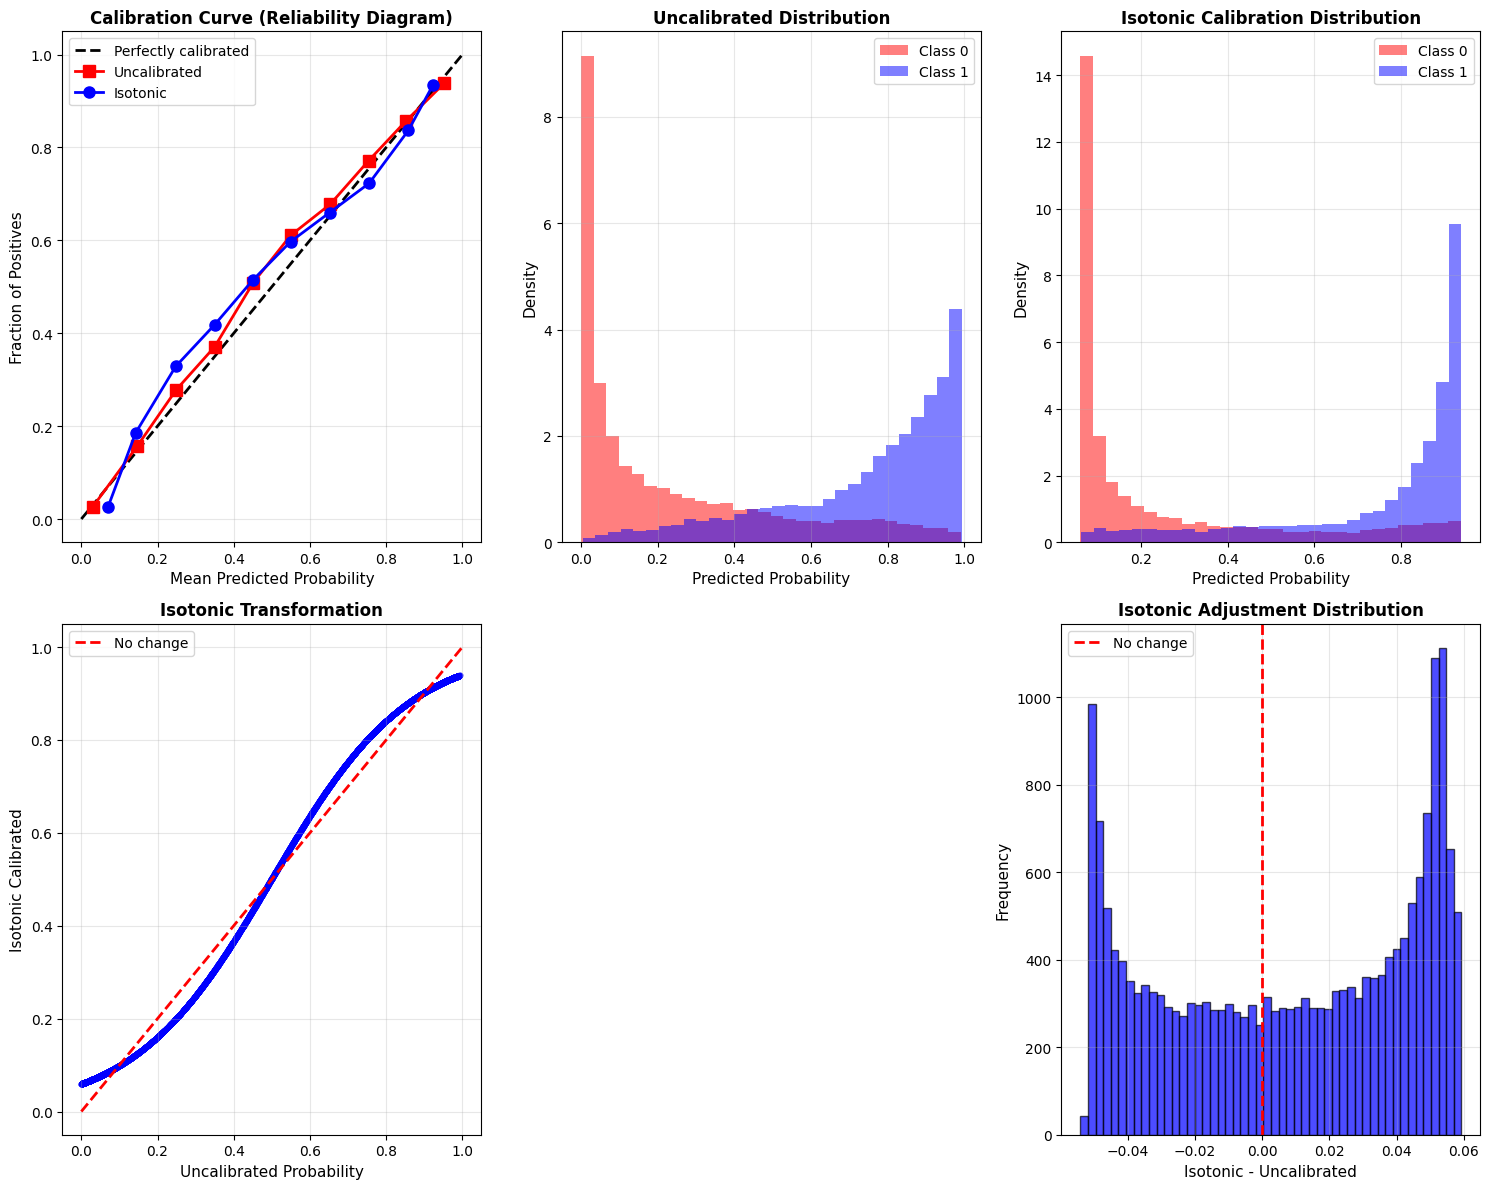

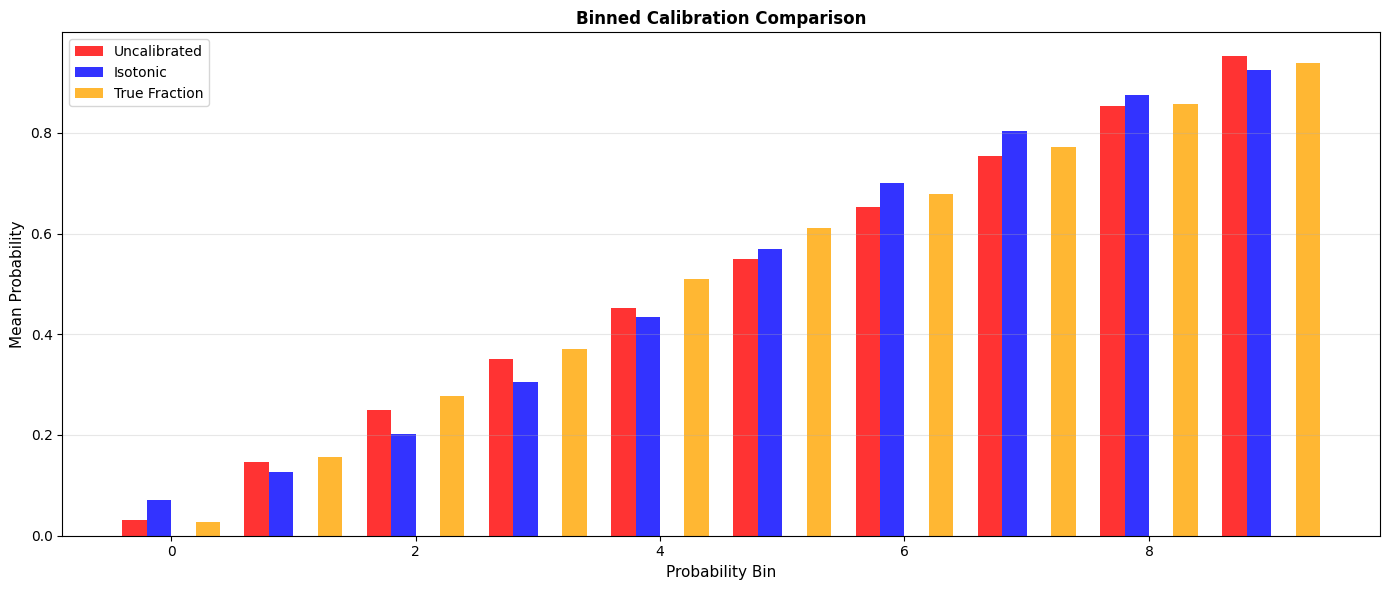


✓ Calibration analysis complete!
  - Plot saved as 'calibration_comparison_full.png'
  - Binned comparison saved as 'calibration_binned_comparison.png'


In [181]:
# ==================== METRICHE ====================
print("\n" + "="*50)
print("COMPARISON METRICS")
print("="*50)

# Brier Score (lower is better)
brier_uncal = brier_score_loss(y_test, uncalibrated_probs[:,1])
brier_platt = brier_score_loss(y_test, calibrated_probs_platt[:,1])
#brier_sigmoid = brier_score_loss(y_test, calibrated_probs_sigmoid[:,1])
print(f"Brier Score (Uncalibrated): {brier_uncal:.4f}")
print(f"Brier Score (Isotonic):     {brier_platt:.4f}")
#print(f"Brier Score (Sigmoid):      {brier_sigmoid:.4f}")

print(f"Improvement Isotonic: {((brier_uncal - brier_platt) / brier_uncal * 100):.2f}%")


# Log Loss (lower is better)
logloss_uncal = log_loss(y_test, uncalibrated_probs[:,1])
logloss_platt = log_loss(y_test, calibrated_probs_platt[:,1])

print(f"\nLog Loss (Uncalibrated): {logloss_uncal:.4f}")
print(f"Log Loss (Isotonic):     {logloss_platt:.4f}")

print(f"Improvement Isotonic: {((logloss_uncal - logloss_platt) / logloss_uncal * 100):.2f}%")


# ROC AUC (dovrebbe rimanere simile)
auc_uncal = roc_auc_score(y_test, uncalibrated_probs[:,1])
auc_platt = roc_auc_score(y_test, calibrated_probs_platt[:,1])

print(f"\nROC AUC (Uncalibrated): {auc_uncal:.4f}")
print(f"ROC AUC (Isotonic):     {auc_platt:.4f}")


# Classification Metrics
print("\n" + "="*50)
print("CLASSIFICATION METRICS")
print("="*50)
print(f"{'Metric':<12} {'Uncalibrated':<15} {'Isotonic':<15} {'Sigmoid':<15}")
print("-" * 57)
print(f"{'Accuracy':<12} {metrics_uncalibrated['accuracy']:<15.4f} {metrics_calibrated_platt['accuracy']:<15.4f} ")
print(f"{'Precision':<12} {metrics_uncalibrated['precision']:<15.4f} {metrics_calibrated_platt['precision']:<15.4f} ")
print(f"{'Recall':<12} {metrics_uncalibrated['recall']:<15.4f} {metrics_calibrated_platt['recall']:<15.4f} ")
print(f"{'F1-Score':<12} {metrics_uncalibrated['f1']:<15.4f} {metrics_calibrated_platt['f1']:<15.4f} ")

# Esempi di probabilità
print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)
print("True | Uncalibrated | Isotonic  | Sigmoid")
print("-" * 48)
for i in range(10):
    print(f" {y_test[i]}   |    {uncalibrated_probs[:,1][i]:.4f}    |  {calibrated_probs_platt[:,1][i]:.4f}  ")

# ==================== VISUALIZZAZIONI ====================
fig = plt.figure(figsize=(20, 12))

# 1. Calibration Curve (Reliability Diagram)
ax1 = plt.subplot(2, 4, 1)
fraction_of_positives_uncal, mean_predicted_value_uncal = calibration_curve(
    y_test, uncalibrated_probs[:,1], n_bins=10, strategy='uniform'
)
fraction_of_positives_platt, mean_predicted_value_platt = calibration_curve(
    y_test, calibrated_probs_platt[:,1], n_bins=10, strategy='uniform'
)


plt.plot([0, 1], [0, 1], 'k--', label='Perfectly calibrated', linewidth=2)
plt.plot(mean_predicted_value_uncal, fraction_of_positives_uncal, 
         's-', label='Uncalibrated', markersize=8, linewidth=2, color='red')
plt.plot(mean_predicted_value_platt, fraction_of_positives_platt, 
         'o-', label='Isotonic', markersize=8, linewidth=2, color='blue')
plt.xlabel('Mean Predicted Probability', fontsize=11)
plt.ylabel('Fraction of Positives', fontsize=11)
plt.title('Calibration Curve (Reliability Diagram)', fontsize=12, fontweight='bold')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# 2. Distribuzione delle probabilità - Uncalibrated
ax2 = plt.subplot(2, 4, 2)
plt.hist(uncalibrated_probs[:,1][y_test == 0], bins=30, alpha=0.5, 
         label='Class 0', color='red', density=True)
plt.hist(uncalibrated_probs[:,1][y_test == 1], bins=30, alpha=0.5, 
         label='Class 1', color='blue', density=True)
plt.xlabel('Predicted Probability', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('Uncalibrated Distribution', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Distribuzione - Isotonic
ax3 = plt.subplot(2, 4, 3)
plt.hist(calibrated_probs_platt[:,1][y_test == 0], bins=30, alpha=0.5, 
         label='Class 0', color='red', density=True)
plt.hist(calibrated_probs_platt[:,1][y_test == 1], bins=30, alpha=0.5, 
         label='Class 1', color='blue', density=True)
plt.xlabel('Predicted Probability', fontsize=11)
plt.ylabel('Density', fontsize=11)
plt.title('Isotonic Calibration Distribution', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)


# 5. Scatter plot: Uncalibrated vs Isotonic
ax5 = plt.subplot(2, 4, 5)
plt.scatter(uncalibrated_probs[:,1], calibrated_probs_platt[:,1], alpha=0.3, s=10, color='blue')
plt.plot([0, 1], [0, 1], 'r--', label='No change', linewidth=2)
plt.xlabel('Uncalibrated Probability', fontsize=11)
plt.ylabel('Isotonic Calibrated', fontsize=11)
plt.title('Isotonic Transformation', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)


# 7. Difference in probabilities - Isotonic
ax7 = plt.subplot(2, 4, 7)
prob_diff_platt = calibrated_probs_platt[:,1] - uncalibrated_probs[:,1]
plt.hist(prob_diff_platt, bins=50, edgecolor='black', alpha=0.7, color='blue')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No change')
plt.xlabel('Isotonic - Uncalibrated', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Isotonic Adjustment Distribution', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)



plt.tight_layout()
plt.savefig('calibration_comparison_full.png', dpi=300, bbox_inches='tight')
plt.show()

# ==================== GRAFICO AGGIUNTIVO: Binned Comparison ====================
fig2 = plt.figure(figsize=(14, 6))

# Binned comparison
bins = np.linspace(0, 1, 11)
bin_indices = np.digitize(uncalibrated_probs[:,1], bins) - 1
bin_means_uncal = [uncalibrated_probs[:,1][bin_indices == i].mean() 
                   for i in range(len(bins)-1) if (bin_indices == i).sum() > 0]
bin_means_platt = [calibrated_probs_platt[:,1][bin_indices == i].mean() 
                      for i in range(len(bins)-1) if (bin_indices == i).sum() > 0]

bin_true = [pd.Series(y_test).iloc[bin_indices == i].mean() 
            for i in range(len(bins)-1) if (bin_indices == i).sum() > 0]

x_pos = np.arange(len(bin_means_uncal))
width = 0.2

ax = plt.subplot(1, 1, 1)
plt.bar(x_pos - 1.5*width, bin_means_uncal, width, label='Uncalibrated', alpha=0.8, color='red')
plt.bar(x_pos - 0.5*width, bin_means_platt, width, label='Isotonic', alpha=0.8, color='blue')
plt.bar(x_pos + 1.5*width, bin_true, width, label='True Fraction', alpha=0.8, color='orange')
plt.xlabel('Probability Bin', fontsize=11)
plt.ylabel('Mean Probability', fontsize=11)
plt.title('Binned Calibration Comparison', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('calibration_binned_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Calibration analysis complete!")
print("  - Plot saved as 'calibration_comparison_full.png'")
print("  - Binned comparison saved as 'calibration_binned_comparison.png'")